In [46]:
## ============================================
# MODEL CREATION
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_b2
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast, GradScaler

# -------------------
# CBAM Block (Attention)
# -------------------
class CBAMBlock(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super(CBAMBlock, self).__init__()
        # Channel Attention
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sigmoid_channel = nn.Sigmoid()
        # Spatial Attention
        self.conv_spatial = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid_spatial = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        # Channel Attention
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        channel_out = self.sigmoid_channel(avg_out + max_out).view(b, c, 1, 1)
        x = x * channel_out
        # Spatial Attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        spatial_out = torch.cat([avg_out, max_out], dim=1)
        spatial_out = self.sigmoid_spatial(self.conv_spatial(spatial_out))
        x = x * spatial_out
        return x

# ---------------------------------------------------------
# Basic Conv Block
# ---------------------------------------------------------
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel=3, dropout=0.3):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.dropout(x)
        return x


# ---------------------------------------------------------
# Residual Block (2 conv blocks + skip)
# ---------------------------------------------------------
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = ConvBlock(channels, channels)
        self.conv2 = ConvBlock(channels, channels)

    def forward(self, x):
        identity = x
        x = self.conv1(x)
        x = self.conv2(x)
        return x + identity


# ---------------------------------------------------------
# BlockTwoSkip (2 residual blocks + skip)
# Paper Section 2.2: "two residual units ... combined with preceding
# representations via a skip connection" -> 6 ResidualBlocks total
# across 3 BlockTwoSkip stages, matching the ablation study's
# "CNN FE x3 + Residual Block x6" (Section 2.7).
# ---------------------------------------------------------
class BlockTwoSkip(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.res1 = ResidualBlock(channels)
        self.res2 = ResidualBlock(channels)

    def forward(self, x):
        identity = x
        x = self.res1(x)
        x = self.res2(x)
        return x + identity
    

# ---------------------------------------------------------
# Graph Convolution Layer
# Paper Section 2.5: 
# --------------------------------------------------------
class GraphConv(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, adj):
        # x: [B, N, C]
        # adj: [N, N]
        out = torch.matmul(adj, x)          # message passing
        out = self.linear(out)
        return F.relu(out)

def build_grid_adj(h, w, device):
    n = h * w
    adj = torch.zeros(n, n, device=device)

    for i in range(h):
        for j in range(w):
            idx = i * w + j
            for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                ni, nj = i+di, j+dj
                if 0 <= ni < h and 0 <= nj < w:
                    nidx = ni * w + nj
                    adj[idx, nidx] = 1

    # self-loop + normalization
    adj += torch.eye(n, device=device)
    deg = adj.sum(dim=1, keepdim=True)
    adj = adj / deg
    return adj

# ---------------------------------------------------------
# Full Model with densenet121 Backbone
# ---------------------------------------------------------
class FERModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # -------- DenseNet Backbone --------
        backbone = models.densenet121(
            weights=models.DenseNet121_Weights.IMAGENET1K_V1
        )
        self.backbone = backbone.features   # [B, 1024, 7, 7]
        in_channels = 1024

        # Feature blocks 
        mid_channels = 128   

        # -------------------
        # Feature extractor
        # -------------------
        self.conv1 = ConvBlock(in_channels, mid_channels, dropout=0.2)
        self.block1 = BlockTwoSkip(mid_channels)

        self.conv2 = ConvBlock(mid_channels, mid_channels, dropout=0.2)
        self.block2 = BlockTwoSkip(mid_channels)

        self.cbam = CBAMBlock(mid_channels)

        self.conv3 = ConvBlock(mid_channels, mid_channels, dropout=0.2)
        self.block3 = BlockTwoSkip(mid_channels)

        # GNN
        self.gnn1 = GraphConv(mid_channels, mid_channels)
        # self.gnn_ln1 = nn.LayerNorm(mid_channels)
        
        self.gnn2 = GraphConv(mid_channels, mid_channels)
        # self.gnn_ln1 = nn.LayerNorm(mid_channels)
        
        self.gnn_fc = nn.Linear(mid_channels, mid_channels)
        # -------------------
        # Classifier
        # -------------------
        self.classifier = nn.Sequential(
            nn.Linear(mid_channels, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
    
        x = self.conv1(x)
        x = self.block1(x)
    
        x = self.conv2(x)
        x = self.block2(x)
    
        x = self.cbam(x)
        x = self.conv3(x)
        x = self.block3(x)
    
        # --------------------
        # CNN → Graph
        # --------------------
        B, C, H, W = x.shape
        nodes = x.view(B, C, H*W).permute(0, 2, 1)  # [B, N, C]
    
        adj = build_grid_adj(H, W, x.device)
    
        nodes = self.gnn1(nodes, adj)
        # nodes = self.gnn_ln1(nodes)
        
        nodes = self.gnn2(nodes, adj)
        # nodes = self.gnn_ln2(nodes)
    
        # Graph pooling
        gnn_feat = nodes.mean(dim=1)   # [B, C]
        gnn_feat = self.gnn_fc(gnn_feat)
        
        # Contribution #3 (paper Section 1): "strategic placement of L2
        # normalization after GNN feature transformation (GNN-FC layer)
        # significantly improves class separation and prevents
        # overfitting" -- previously missing, now added.
        
        # gnn_feat = F.normalize(gnn_feat, p=2, dim=-1)
    
        # --------------------
        # Final classifier
        # --------------------
        logits = self.classifier(gnn_feat)
        return logits


In [48]:
EPOCHS = 100                # لا تحتاج 200
BATCH_SIZE = 32             # لو GPU يسمح
LR = 3e-4                   # أعلى قليلًا للبداية السريعة
WEIGHT_DECAY = 1e-4
PATIENCE = 15               # EarlyStopping
FREEZE_EPOCHS = 10          # تجميد EfficientNet
#MIX_PROB = 0.2              # MixUp + CutMix
LABEL_SMOOTHING = 0.1
mixup_alpha = 0.2
mixup_prob  = 0.3
cutmix_prob = 0.0   # ❌ ممنوع

In [49]:
def freeze_backbone(model):
    for p in model.backbone.parameters():
        p.requires_grad = False

def unfreeze_backbone(model):
    for p in model.backbone.parameters():
        p.requires_grad = True


In [50]:
class EarlyStopping:
    def __init__(self, patience=15):
        self.patience = patience
        self.counter = 0
        self.best_acc = 0

    def step(self, val_acc):
        if val_acc > self.best_acc:
            self.best_acc = val_acc
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience


In [51]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

# -------------------
# Training Function
# -------------------
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=50):
    model.to(device)
    best_val_acc = 0.0
    scaler = GradScaler()
    #early_stopping = EarlyStopping(patience=PATIENCE)

    best_val_acc = 0.0
    freeze_backbone(model)
    for epoch in range(epochs):
        if epoch == FREEZE_EPOCHS:
            unfreeze_backbone(model)
            print("🔓 Backbone Unfrozen")
        
        model.train()
        train_loss, train_correct, total = 0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss /= total
        train_acc = 100. * train_correct / total

        # ---- Validation ----
        model.eval()
        val_loss, val_correct, total_val = 0, 0, 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Validation]"):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                total_val += labels.size(0)

        val_loss /= total_val
        val_acc = 100. * val_correct / total_val

        print(f"\nEpoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print(f"✅ Best model saved with Val Acc: {val_acc:.2f}%")

    print("Training Finished! Best Val Acc: {:.2f}%".format(best_val_acc))
    return model


In [52]:
def set_seed(seed=42):
    import random, numpy as np, torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [53]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import torch

# -------------------
# Load dataset
# -------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  std=[0.229, 0.224, 0.225]),
])


full_dataset = datasets.ImageFolder('/kaggle/input/ck-dataset', transform=transform)
emotion_labels = full_dataset.classes
print("Emotion labels:", emotion_labels)

# -------------------
# Split dataset (80/10/10)
# -------------------
train_size = int(0.80 * len(full_dataset))
val_size   = int(0.20 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size  # remaining samples

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # for reproducibility
)

# -------------------
# Create DataLoaders
# -------------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

# -------------------
# Create DataLoaders
# -------------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
#test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

model = FERModel(num_classes=len(emotion_labels)).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=100
)

trained_model = train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=100)


Emotion labels: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']


/tmp/ipykernel_17070/4016826701.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/100 [Validation]: 100%|██████████| 7/7 [00:00<00:00,  8.57it/s]



Epoch [1/100] Train Loss: 1.7676 | Train Acc: 36.35% Val Loss: 1.8290 | Val Acc: 35.20%
✅ Best model saved with Val Acc: 35.20%


Epoch 2/100 [Validation]: 100%|██████████| 7/7 [00:00<00:00,  8.40it/s]



Epoch [2/100] Train Loss: 1.4516 | Train Acc: 55.74% Val Loss: 1.6852 | Val Acc: 41.84%
✅ Best model saved with Val Acc: 41.84%


...


Epoch [98/100] Train Loss: 0.4773 | Train Acc: 99.87% Val Loss: 0.5071 | Val Acc: 98.47%


Epoch 99/100 [Validation]: 100%|██████████| 7/7 [00:00<00:00,  8.45it/s]



Epoch [99/100] Train Loss: 0.4728 | Train Acc: 100.00% Val Loss: 0.5097 | Val Acc: 98.47%


Epoch 100/100 [Validation]: 100%|██████████| 7/7 [00:00<00:00,  8.62it/s]


Epoch [100/100] Train Loss: 0.4721 | Train Acc: 100.00% Val Loss: 0.5080 | Val Acc: 98.47%
Training Finished! Best Val Acc: 100.00%


In [54]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# -------------------
# Evaluation Function
# -------------------
def evaluate_model(model, val_loader, device, emotion_labels):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Accuracy
    accuracy = 100 * (torch.tensor(all_preds) == torch.tensor(all_labels)).sum().item() / len(all_labels)
    print(f"✅ Test Accuracy: {accuracy:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=emotion_labels,
                yticklabels=emotion_labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # Classification Report
    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=emotion_labels))


✅ Test Accuracy: 100.00%


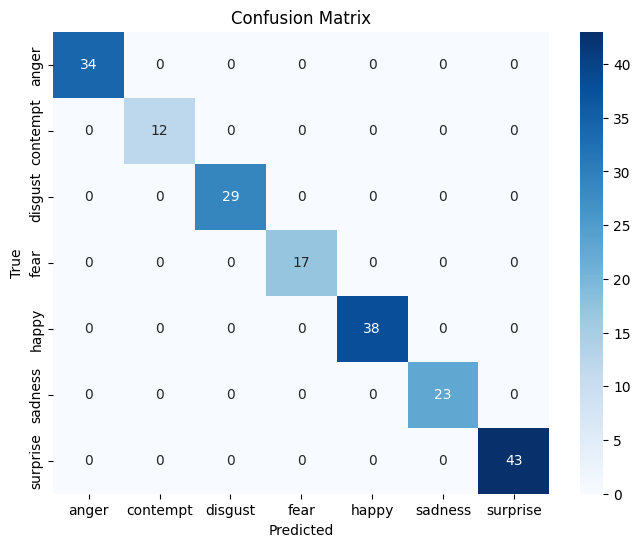


📊 Classification Report:
              precision    recall  f1-score   support

       anger       1.00      1.00      1.00        34
    contempt       1.00      1.00      1.00        12
     disgust       1.00      1.00      1.00        29
        fear       1.00      1.00      1.00        17
       happy       1.00      1.00      1.00        38
     sadness       1.00      1.00      1.00        23
    surprise       1.00      1.00      1.00        43

    accuracy                           1.00       196
   macro avg       1.00      1.00      1.00       196
weighted avg       1.00      1.00      1.00       196



In [55]:
# Evaluate the best trained model
best_model = FERModel(num_classes=len(emotion_labels)).to(device)
best_model.load_state_dict(torch.load("best_model.pth"))  # load saved best weights

evaluate_model(best_model, val_loader, device, emotion_labels)


## 5-Fold Stratified Cross-Validation

In [ ]:
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from torchvision import transforms

# ── CK+ Dataset Class ──────────────────────────────────────────────────────
class CKPlusDataset(Dataset):
    """
    هيكل مجلدات CK+:
    CK+/
    ├── angry/
    │   ├── S005_001_00000011.png
    │   └── ...
    ├── contempt/
    ├── disgust/
    ├── fear/
    ├── happy/
    ├── sadness/
    └── surprise/
    """

    EMOTIONS = ['anger', 'contempt', 'disgust',
                'fear', 'happy', 'sadness', 'surprise']

    def __init__(self, root_dir, transform=None):
        self.root_dir  = root_dir
        self.transform = transform
        self.samples   = []   # list of (img_path, label)
        self.subjects  = []   # subject ID per sample (for LOSO option)

        for label, emotion in enumerate(self.EMOTIONS):
            emotion_dir = os.path.join(root_dir, emotion)
            if not os.path.isdir(emotion_dir):
                continue
            for fname in sorted(os.listdir(emotion_dir)):
                if fname.lower().endswith(('.png','.jpg','.jpeg')):
                    fpath = os.path.join(emotion_dir, fname)
                    self.samples.append((fpath, label))
                    # CK+ filenames: S005_001_... → subject = S005
                    subject = fname.split('_')[0]
                    self.subjects.append(subject)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

In [ ]:
# ── Transforms ──────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np

def train_one_fold(model, train_loader, test_loader,
                   fold_num, device,
                   num_epochs=50, patience=15):
    """
    يدرّب ويقيّم fold واحد.
    Returns: best_acc, best_f1, all_preds, all_labels
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    best_acc     = 0.0
    best_f1      = 0.0
    best_preds   = []
    best_labels  = []
    no_improve   = 0

    print(f"\n{'='*50}")
    print(f"  Fold {fold_num} — Training")
    print(f"{'='*50}")

    for epoch in range(1, num_epochs + 1):

        # ── Train ────────────────────────────────────────
        model.train()
        train_loss, correct, total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)

        scheduler.step()
        train_acc  = correct / total
        train_loss = train_loss / total

        # ── Evaluate ─────────────────────────────────────
        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs   = imgs.to(device)
                outputs = model(imgs)
                preds   = outputs.argmax(dim=1).cpu().tolist()
                all_preds  .extend(preds)
                all_labels .extend(labels.tolist())

        acc = accuracy_score(all_labels, all_preds) * 100
        f1  = f1_score(all_labels, all_preds,
                       average='weighted') * 100

        print(f"Epoch {epoch:03d}/{num_epochs} | "
              f"Loss={train_loss:.4f} | "
              f"TrainAcc={train_acc*100:.2f}% | "
              f"TestAcc={acc:.2f}% | F1={f1:.2f}%")

        # ── Early Stopping ────────────────────────────────
        if acc > best_acc:
            best_acc    = acc
            best_f1     = f1
            best_preds  = all_preds.copy()
            best_labels = all_labels.copy()
            no_improve  = 0
            # احفظ أحسن weights
            torch.save(model.state_dict(),
                       f'best_fold{fold_num}.pt')
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  ⏹ Early stopping at epoch {epoch}")
                break

    print(f"\n  ✅ Fold {fold_num} Best Acc = {best_acc:.2f}% | "
          f"F1 = {best_f1:.2f}%")

    return best_acc, best_f1, best_preds, best_labels

In [ ]:
from sklearn.model_selection import StratifiedKFold
import copy

def run_5fold_ckplus(root_dir, device, num_classes=7):
    """
    يشغّل 5-Fold Cross-Validation كاملة على CK+
    """

    # ── Load full dataset ────────────────────────────────
    full_dataset = CKPlusDataset(root_dir, transform=train_transform)

    # الـ labels لكل sample (مطلوبة لـ StratifiedKFold)
    all_labels = [full_dataset.samples[i][1]
                  for i in range(len(full_dataset))]

    print(f"📦 Total samples: {len(full_dataset)}")
    print(f"📊 Classes: {CKPlusDataset.EMOTIONS}")

    # ── Stratified 5-Fold ────────────────────────────────
    # Stratified = كل fold فيها نفس نسبة كل class
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    fold_results = []   # (acc, f1) لكل fold
    all_preds_combined  = []
    all_labels_combined = []

    for fold, (train_idx, test_idx) in enumerate(
            skf.split(range(len(full_dataset)), all_labels), start=1):

        print(f"\n{'━'*60}")
        print(f"  FOLD {fold}/5 | "
              f"Train={len(train_idx)} | Test={len(test_idx)}")
        print(f"{'━'*60}")

        # ── Samplers ─────────────────────────────────────
        # train dataset: بيستخدم train_transform
        # test dataset:  بيستخدم test_transform (بدون augmentation)
        train_dataset = CKPlusDataset(root_dir,
                                       transform=train_transform)
        test_dataset  = CKPlusDataset(root_dir,
                                       transform=test_transform)

        train_loader = DataLoader(
            train_dataset,
            batch_size=32,
            sampler=SubsetRandomSampler(train_idx),
            num_workers=2,
            pin_memory=True,
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=32,
            sampler=SubsetRandomSampler(test_idx),
            num_workers=2,
            pin_memory=True,
        )

        # ── Fresh model لكل fold ──────────────────────────
        model = FERModel(num_classes=num_classes).to(device)

        # ── Train ─────────────────────────────────────────
        acc, f1, preds, labels = train_one_fold(
            model, train_loader, test_loader,
            fold_num=fold,
            device=device,
            num_epochs=100,
            patience=50,
        )

        fold_results.append((acc, f1))
        all_preds_combined .extend(preds)
        all_labels_combined.extend(labels)

    # ────────────────────────────────────────────────────
    # النتائج النهائية
    # ────────────────────────────────────────────────────
    accs = [r[0] for r in fold_results]
    f1s  = [r[1] for r in fold_results]

    print(f"\n{'═'*60}")
    print(f"  5-FOLD CROSS-VALIDATION RESULTS — CK+")
    print(f"{'═'*60}")
    for i, (acc, f1) in enumerate(fold_results, 1):
        print(f"  Fold {i}: Acc={acc:.2f}%  F1={f1:.2f}%")
    print(f"{'─'*60}")
    print(f"  Mean Acc : {np.mean(accs):.2f}% ± {np.std(accs):.2f}%")
    print(f"  Mean F1  : {np.mean(f1s):.2f}% ± {np.std(f1s):.2f}%")
    print(f"  Best Fold: {np.argmax(accs)+1} ({max(accs):.2f}%)")
    print(f"{'═'*60}")

    # Confusion matrix على كل الـ predictions
    cm = confusion_matrix(all_labels_combined, all_preds_combined)
    print(f"\n  Confusion Matrix (all folds combined):")
    print(cm)

    return {
        'fold_results'   : fold_results,
        'mean_acc'       : np.mean(accs),
        'std_acc'        : np.std(accs),
        'mean_f1'        : np.mean(f1s),
        'std_acc'        : np.std(accs),
        'confusion_matrix': cm,
    }

In [ ]:
if __name__ == "__main__":
    device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    root_dir = "/kaggle/input/ck-dataset"  # ← غيّر المسار

    results = run_5fold_ckplus(root_dir, device, num_classes=7)

## ROC Curve & AUC Visualization (Multi-Class, One-vs-Rest)

Since this is a multi-class problem (7 emotion classes), AUC is computed using the **One-vs-Rest (OvR)** strategy: for each class, treat it as the "positive" class and all others as "negative," then compute a ROC curve and AUC. This also reports **macro-average** (unweighted mean across classes) and **micro-average** (aggregated across all classes, sensitive to class imbalance) AUC.

This requires **predicted probabilities** (softmax outputs), not just the final predicted labels — so a small helper collects `softmax` scores alongside true labels.


In [ ]:
# ============================================================
# ROC CURVE & AUC (Multi-Class, One-vs-Rest)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle


def get_probs_and_labels(model, data_loader, device):
    """Runs the model over a DataLoader and collects softmax probabilities
    plus true labels (needed for ROC/AUC, unlike argmax-only evaluation)."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_probs, axis=0), np.concatenate(all_labels, axis=0)


def plot_multiclass_roc_auc(y_true, y_probs, class_names, title="ROC Curves (One-vs-Rest)"):
    """
    y_true:  1D array of integer class labels, shape [N]
    y_probs: 2D array of predicted probabilities, shape [N, num_classes]
    """
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    # Handle the edge case of a binary problem (label_binarize returns 1 column)
    if n_classes == 2:
        y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # ---- Micro-average (aggregate all classes together) ----
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # ---- Macro-average (unweighted mean of per-class curves) ----
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # ---- Plot ----
    plt.figure(figsize=(9, 7))
    colors = cycle(["#e6194B", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
                     "#911eb4", "#42d4f4", "#f032e6", "#bfef45", "#fabed4"])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                  label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

    plt.plot(fpr["micro"], tpr["micro"], linestyle=":", color="deeppink", lw=3,
              label=f"micro-average (AUC = {roc_auc['micro']:.3f})")
    plt.plot(fpr["macro"], tpr["macro"], linestyle=":", color="navy", lw=3,
              label=f"macro-average (AUC = {roc_auc['macro']:.3f})")

    plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance (AUC = 0.500)")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nPer-class AUC:")
    for i in range(n_classes):
        print(f"  {class_names[i]:>10s}: {roc_auc[i]:.4f}")
    print(f"\n  Macro-average AUC: {roc_auc['macro']:.4f}")
    print(f"  Micro-average AUC: {roc_auc['micro']:.4f}")

    return roc_auc


In [ ]:
# ============================================================
# RUN: ROC / AUC on the held-out test set (single 80/20 split model)
# ============================================================
y_probs, y_true = get_probs_and_labels(best_model, val_loader, device)
roc_auc_scores = plot_multiclass_roc_auc(y_true, y_probs, emotion_labels,
                                          title="DRAG-Net ROC Curves (Test Set)")


## Exploratory Data Analysis (EDA)

Visualizes: (1) class distribution across the dataset, (2) sample images per class, (3) basic image statistics (size/aspect ratio). Run this once `full_dataset` (an `ImageFolder`) is loaded.


In [ ]:
# ============================================================
# EDA: CLASS DISTRIBUTION + SAMPLE IMAGES
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from PIL import Image
import random

def plot_class_distribution(dataset, class_names, title="Class Distribution"):
    """Bar chart of image counts per class, with counts + percentages labeled."""
    targets = np.array(dataset.targets)
    counts = Counter(targets)
    counts_ordered = [counts.get(i, 0) for i in range(len(class_names))]
    total = sum(counts_ordered)

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
    bars = ax.bar(class_names, counts_ordered, color=colors, edgecolor="black")

    for bar, count in zip(bars, counts_ordered):
        pct = 100 * count / total
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(counts_ordered) * 0.01,
                 f"{count}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

    ax.set_ylabel("Number of Images")
    ax.set_title(f"{title}  (Total: {total} images)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    print("Class distribution:")
    for i, name in enumerate(class_names):
        print(f"  {name:>10s}: {counts_ordered[i]:5d}  ({100*counts_ordered[i]/total:.2f}%)")
    imbalance_ratio = max(counts_ordered) / max(min(counts_ordered), 1)
    print(f"\nImbalance ratio (max/min class): {imbalance_ratio:.2f}x")


def plot_sample_images(dataset, class_names, samples_per_class=4, title="Sample Images per Class"):
    """Grid of randomly sampled images, one row per class."""
    targets = np.array(dataset.targets)
    n_classes = len(class_names)

    fig, axes = plt.subplots(n_classes, samples_per_class,
                              figsize=(samples_per_class * 2.2, n_classes * 2.2))
    if n_classes == 1:
        axes = axes[np.newaxis, :]

    for row, class_idx in enumerate(range(n_classes)):
        class_indices = np.where(targets == class_idx)[0]
        chosen = random.sample(list(class_indices), min(samples_per_class, len(class_indices)))
        for col in range(samples_per_class):
            ax = axes[row, col]
            if col < len(chosen):
                img_path, _ = dataset.samples[chosen[col]]
                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(class_names[class_idx], fontsize=10)
                ax.text(-0.15, 0.5, class_names[class_idx], transform=ax.transAxes,
                        fontsize=11, va="center", ha="right", rotation=90)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_image_size_stats(dataset, sample_size=200, title="Image Size Distribution (sampled)"):
    """Checks whether images have consistent resolution/aspect ratio before resizing."""
    n = min(sample_size, len(dataset.samples))
    sampled = random.sample(dataset.samples, n)
    widths, heights = [], []
    for img_path, _ in sampled:
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].scatter(widths, heights, alpha=0.5, s=15)
    axes[0].set_xlabel("Width (px)")
    axes[0].set_ylabel("Height (px)")
    axes[0].set_title("Width vs Height")
    axes[0].grid(alpha=0.3)

    aspect_ratios = np.array(widths) / np.array(heights)
    axes[1].hist(aspect_ratios, bins=20, color="teal", edgecolor="black")
    axes[1].set_xlabel("Aspect Ratio (W/H)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Aspect Ratio Distribution")
    axes[1].grid(alpha=0.3)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    print(f"Sampled {n} images | Width: {np.mean(widths):.0f}\u00b1{np.std(widths):.0f}px | "
          f"Height: {np.mean(heights):.0f}\u00b1{np.std(heights):.0f}px")


In [ ]:
# ============================================================
# RUN EDA
# ============================================================
plot_class_distribution(full_dataset, emotion_labels, title="Dataset Class Distribution")
plot_sample_images(full_dataset, emotion_labels, samples_per_class=4)
plot_image_size_stats(full_dataset, sample_size=200)


## Precision-Recall (PR) Curves (Multi-Class, One-vs-Rest)

Complements the ROC/AUC analysis above. PR curves are especially informative for **imbalanced classes** (e.g., 'disgust' or 'fear' typically under-represented in FER datasets), since ROC-AUC can look overly optimistic under class imbalance while PR-AUC (Average Precision) is more sensitive to it.


In [ ]:
# ============================================================
# PRECISION-RECALL CURVES (Multi-Class, One-vs-Rest)
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from itertools import cycle


def plot_multiclass_pr_curves(y_true, y_probs, class_names, title="Precision-Recall Curves (One-vs-Rest)"):
    """
    y_true:  1D array of integer class labels, shape [N]
    y_probs: 2D array of predicted probabilities, shape [N, num_classes]
    """
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
    if n_classes == 2:
        y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])

    precision, recall, avg_precision = {}, {}, {}
    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        avg_precision[i] = average_precision_score(y_true_bin[:, i], y_probs[:, i])

    # micro-average (aggregate across all classes)
    precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_bin.ravel(), y_probs.ravel())
    avg_precision["micro"] = average_precision_score(y_true_bin, y_probs, average="micro")

    # macro-average AP (unweighted mean across classes)
    avg_precision["macro"] = average_precision_score(y_true_bin, y_probs, average="macro")

    plt.figure(figsize=(9, 7))
    colors = cycle(["#e6194B", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
                     "#911eb4", "#42d4f4", "#f032e6", "#bfef45", "#fabed4"])
    for i, color in zip(range(n_classes), colors):
        plt.plot(recall[i], precision[i], color=color, lw=2,
                  label=f"{class_names[i]} (AP = {avg_precision[i]:.3f})")

    plt.plot(recall["micro"], precision["micro"], linestyle=":", color="deeppink", lw=3,
              label=f"micro-average (AP = {avg_precision['micro']:.3f})")

    # baseline = positive class prevalence (a flat line, differs per class in a real multi-class
    # setting, so we show the overall/micro prevalence as a reference)
    baseline = y_true_bin.sum() / y_true_bin.size
    plt.axhline(baseline, linestyle="--", color="gray", lw=1,
                label=f"Chance level (prevalence = {baseline:.3f})")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend(loc="lower left", fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nPer-class Average Precision (AP):")
    for i in range(n_classes):
        print(f"  {class_names[i]:>10s}: {avg_precision[i]:.4f}")
    print(f"\n  Macro-average AP: {avg_precision['macro']:.4f}")
    print(f"  Micro-average AP: {avg_precision['micro']:.4f}")

    return avg_precision


In [ ]:
# ============================================================
# RUN: Precision-Recall curves on the held-out test set
# ============================================================
# Reuses y_probs / y_true already computed in the ROC/AUC section above.
# If running this section standalone, uncomment the next line:
# y_probs, y_true = get_probs_and_labels(best_model, val_loader, device)

pr_ap_scores = plot_multiclass_pr_curves(y_true, y_probs, emotion_labels,
                                          title="DRAG-Net Precision-Recall Curves (Test Set)")


## Confusion Matrix Heatmap

Shows per-class prediction errors as a heatmap — both raw counts and row-normalized (recall-per-class) versions. This is the standard companion figure to precision/recall/F1 tables in FER papers, and makes it immediately visible which emotions get confused with which (e.g., 'fear' vs 'surprise' is a very common confusion pair in FER).


In [ ]:
# ============================================================
# CONFUSION MATRIX HEATMAP (raw counts + row-normalized)
# ============================================================
import seaborn as sns
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix_heatmap(y_true, y_pred, class_names, title="Confusion Matrix"):
    """Plots two side-by-side heatmaps: raw counts, and row-normalized
    (i.e. recall per true class -- each row sums to 100%)."""
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={"label": "Count"}, ax=axes[0])
    axes[0].set_title(f"{title} (Raw Counts)")
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")

    sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={"label": "% of True Class"}, vmin=0, vmax=100, ax=axes[1])
    axes[1].set_title(f"{title} (Row-Normalized %)")
    axes[1].set_xlabel("Predicted Label")
    axes[1].set_ylabel("True Label")

    plt.tight_layout()
    plt.show()

    # Print the most confused class pairs (excluding the diagonal)
    off_diag = cm.copy()
    np.fill_diagonal(off_diag, 0)
    print("Top confused class pairs (true -> predicted):")
    flat_idx = np.argsort(off_diag, axis=None)[::-1][:5]
    for idx in flat_idx:
        i, j = np.unravel_index(idx, off_diag.shape)
        if off_diag[i, j] > 0:
            print(f"  {class_names[i]:>10s} -> {class_names[j]:<10s}: {off_diag[i, j]} samples "
                  f"({100*off_diag[i, j]/cm[i].sum():.1f}% of true '{class_names[i]}')")

    return cm


In [ ]:
# ============================================================
# RUN: Confusion Matrix Heatmap on the held-out test set
# ============================================================
y_pred = np.argmax(y_probs, axis=1)   # reuses y_probs/y_true from the ROC/AUC section
cm = plot_confusion_matrix_heatmap(y_true, y_pred, emotion_labels,
                                    title="DRAG-Net Confusion Matrix (Test Set)")


## Spatial Attention Heatmap (CBAM / Grad-CAM Style)

Since CBAM is a headline component of DRAG-Net, this visualizes **where the model is spatially "looking"** on the face when making a prediction — overlaying a heatmap on the original image. This uses Grad-CAM on the CBAM-refined feature map (right before the graph transform), which is exactly the representation the paper claims is enhanced by channel-spatial attention. This is a very common and expected figure in FER papers using attention mechanisms, and directly visualizes Contribution about CBAM rather than just reporting accuracy numbers.


In [ ]:
# ============================================================
# SPATIAL ATTENTION HEATMAP (Grad-CAM on the post-CBAM feature map)
# ============================================================
import cv2

class GradCAMHook:
    """Captures the forward activation and backward gradient of a target
    layer (here: the CBAM output, i.e. self.cbam) via forward/backward hooks."""
    def __init__(self, model, target_layer):
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()


def generate_gradcam(model, image_tensor, target_class, device, hook):
    """image_tensor: [1, 3, H, W] (already normalized, batch size 1)."""
    model.eval()
    image_tensor = image_tensor.to(device).requires_grad_(True)

    output = model(image_tensor)
    model.zero_grad()
    score = output[0, target_class]
    score.backward()

    # Grad-CAM: weight each channel by the mean of its gradient, then ReLU
    gradients = hook.gradients[0]          # [C, H, W]
    activations = hook.activations[0]      # [C, H, W]
    weights = gradients.mean(dim=(1, 2))   # [C]

    cam = torch.zeros(activations.shape[1:], device=device)
    for c, w in enumerate(weights):
        cam += w * activations[c]
    cam = F.relu(cam)
    cam = cam.cpu().numpy()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam, output.softmax(dim=1)[0].detach().cpu().numpy()


def unnormalize_image(image_tensor, mean, std):
    """Reverses ImageNet normalization for display purposes."""
    img = image_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)


def plot_attention_heatmaps(model, dataset, class_names, device,
                             mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225),
                             samples_per_class=2, seed=42):
    """Grid: original image | heatmap overlay, for a few random samples per class."""
    hook = GradCAMHook(model, model.cbam)
    random.seed(seed)
    targets = np.array(dataset.targets)

    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes, samples_per_class * 2,
                              figsize=(samples_per_class * 4.4, n_classes * 2.4))

    for row, class_idx in enumerate(range(n_classes)):
        class_indices = np.where(targets == class_idx)[0]
        chosen = random.sample(list(class_indices), min(samples_per_class, len(class_indices)))

        for s, idx in enumerate(chosen):
            image_tensor, true_label = dataset[idx]
            image_batch = image_tensor.unsqueeze(0)

            cam, probs = generate_gradcam(model, image_batch, true_label, device, hook)
            pred_label = int(np.argmax(probs))

            img_np = unnormalize_image(image_tensor, mean, std)
            cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
            heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
            overlay = 0.55 * img_np + 0.45 * heatmap

            ax_img = axes[row, s * 2]
            ax_img.imshow(img_np)
            ax_img.axis("off")
            if s == 0:
                ax_img.set_ylabel(class_names[class_idx], fontsize=10)

            ax_heat = axes[row, s * 2 + 1]
            ax_heat.imshow(overlay)
            ax_heat.axis("off")
            correct = "\u2713" if pred_label == true_label else "\u2717"
            ax_heat.set_title(f"pred: {class_names[pred_label]} {correct}", fontsize=8)

    plt.suptitle("Spatial Attention (CBAM Grad-CAM) — Original vs Overlay", fontsize=13)
    plt.tight_layout()
    plt.show()


In [ ]:
# ============================================================
# RUN: Attention heatmaps for a few samples per class
# ============================================================
# NOTE: requires opencv-python (`pip install opencv-python`) -- usually preinstalled on Kaggle.
plot_attention_heatmaps(best_model, full_dataset, emotion_labels, device, samples_per_class=2)
